In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [3]:
import re

concepts_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/extended_concepts.txt'
def parse_concepts(filepath):
    """Legge il file dei concetti e restituisce una lista ordinata."""
    concepts = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome del concetto
            if len(parts) >= 2:
                concepts.append(parts[1])
    return concepts
concepts = parse_concepts(concepts_file)

In [4]:
import re

classes_file = '../AwA2_Dataset_Labels/Animals_with_Attributes2/classes.txt'
def parse_classes(filepath):
    """Legge il file delle classi e restituisce una lista ordinata."""
    classes = []
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            # Rimuove eventuali tag come 
            line = re.sub(r'\\', '', line).strip()
            if not line:
                continue
            parts = line.split()
            # Assumiamo che il primo elemento sia l'ID e il resto il nome della classe
            if len(parts) >= 2:
                classes.append(parts[1])
    return classes

classes = parse_classes(classes_file)

In [5]:
import json

JSON_PATH='../AwA2_Dataset_Labels/Animals_with_Attributes2/supervisioni_gerarchia.json'
def load_data(json_path, concepts):
    with open(json_path, 'r') as f:
        data = json.load(f)
        
    concept2id = {c: idx for idx, c in enumerate(concepts)}
    id2concept = {idx: c for c, idx in concept2id.items()}
    
    # Prepariamo il dataset nel formato [(id_i, id_j, label), ...]
    dataset = []
    for item in data:
        dataset.append((concept2id[item[0]], concept2id[item[1]], float(item[2])))
        
    return dataset, concept2id, id2concept

In [6]:
dataset, concept2id, id2concept = load_data(JSON_PATH, concepts)

### Train

In [7]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box
import torch.nn as nn
from torch.optim import Adam

LR = 0.05

model = BoxHierarchyModel(num_concepts=len(concept2id), dim=32)
optimizer = Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss() # Binary Cross Entropy

AllenNLP not available. Registrable won't work.


In [8]:
train_box(model, optimizer, criterion, dataset, concept2id, id2concept)

Trovati 50 concetti unici e 583 relazioni supervisionate.

Inizio Addestramento...
Epoca [1/100] | Loss: 1.3447
Epoca [10/100] | Loss: 0.1819
Epoca [20/100] | Loss: 0.0487
Epoca [30/100] | Loss: 0.0199
Epoca [40/100] | Loss: 0.0104
Epoca [50/100] | Loss: 0.0063
Epoca [60/100] | Loss: 0.0045
Epoca [70/100] | Loss: 0.0038
Epoca [80/100] | Loss: 0.0033
Epoca [90/100] | Loss: 0.0030
Epoca [100/100] | Loss: 0.0028

Addestramento completato!

Verifica di alcune predizioni post-addestramento:
Relazione: Animal | arm
 - P_teorica: 1.0 -> P_predetta: 0.9991
Relazione: lower_body_part | big
 - P_teorica: 0.0 -> P_predetta: 0.0039
Relazione: yellow | wings
 - P_teorica: 0.0 -> P_predetta: 0.0000


### Visualization

In [9]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

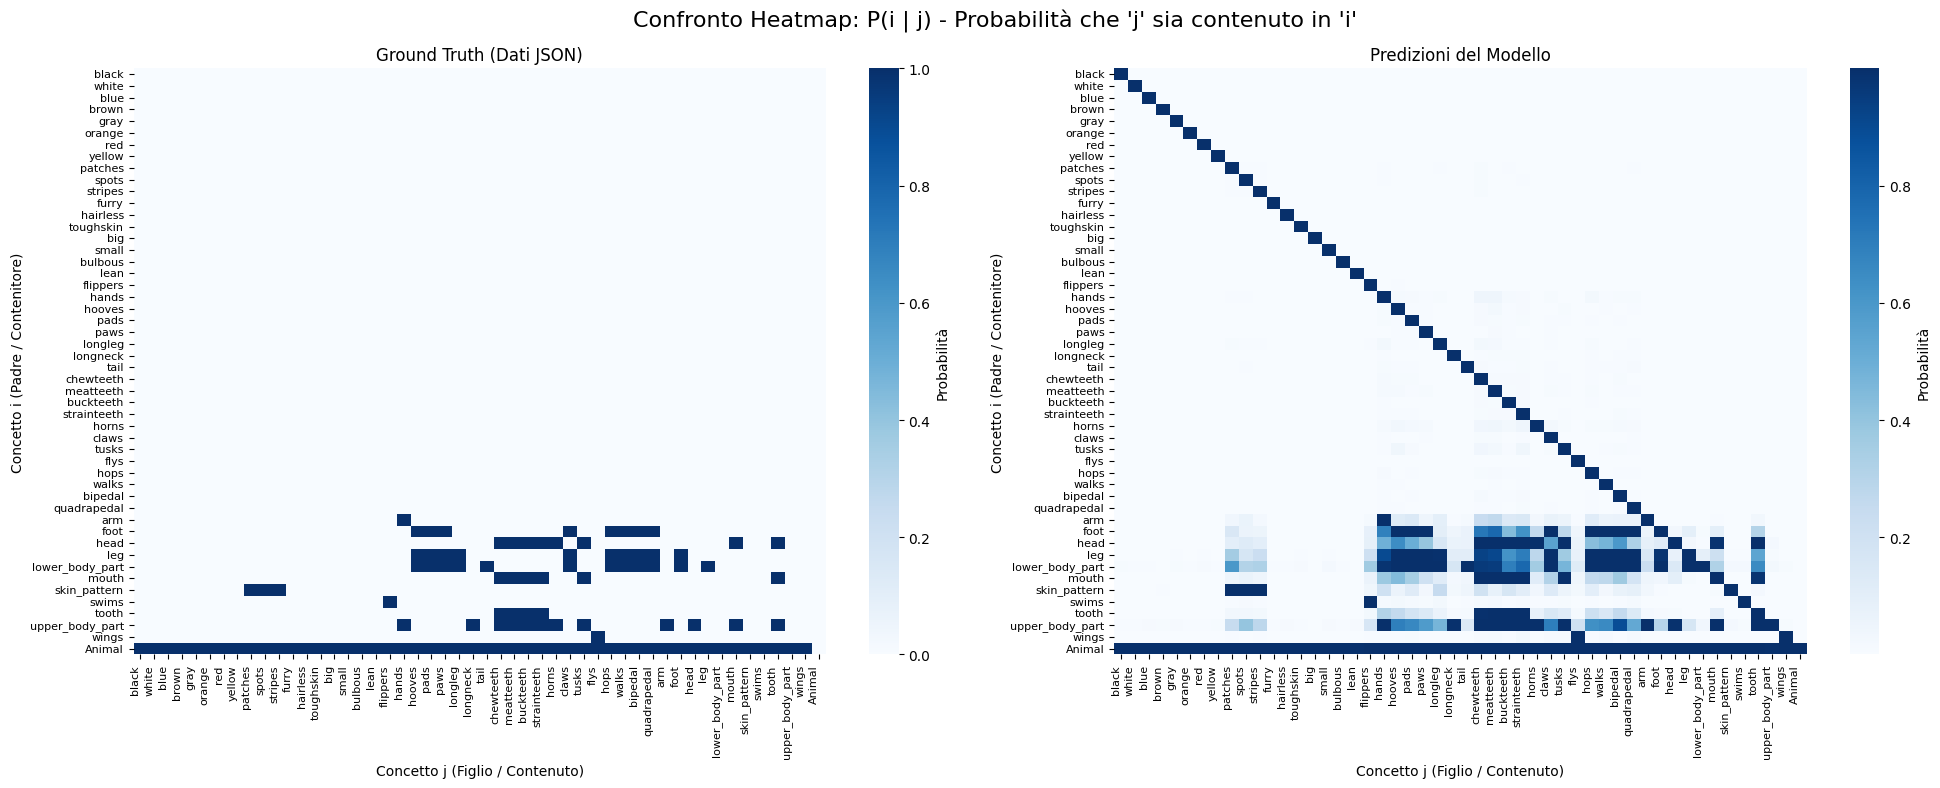

In [10]:
visualize_heatmap_compare(model, dataset, concept2id, id2concept)

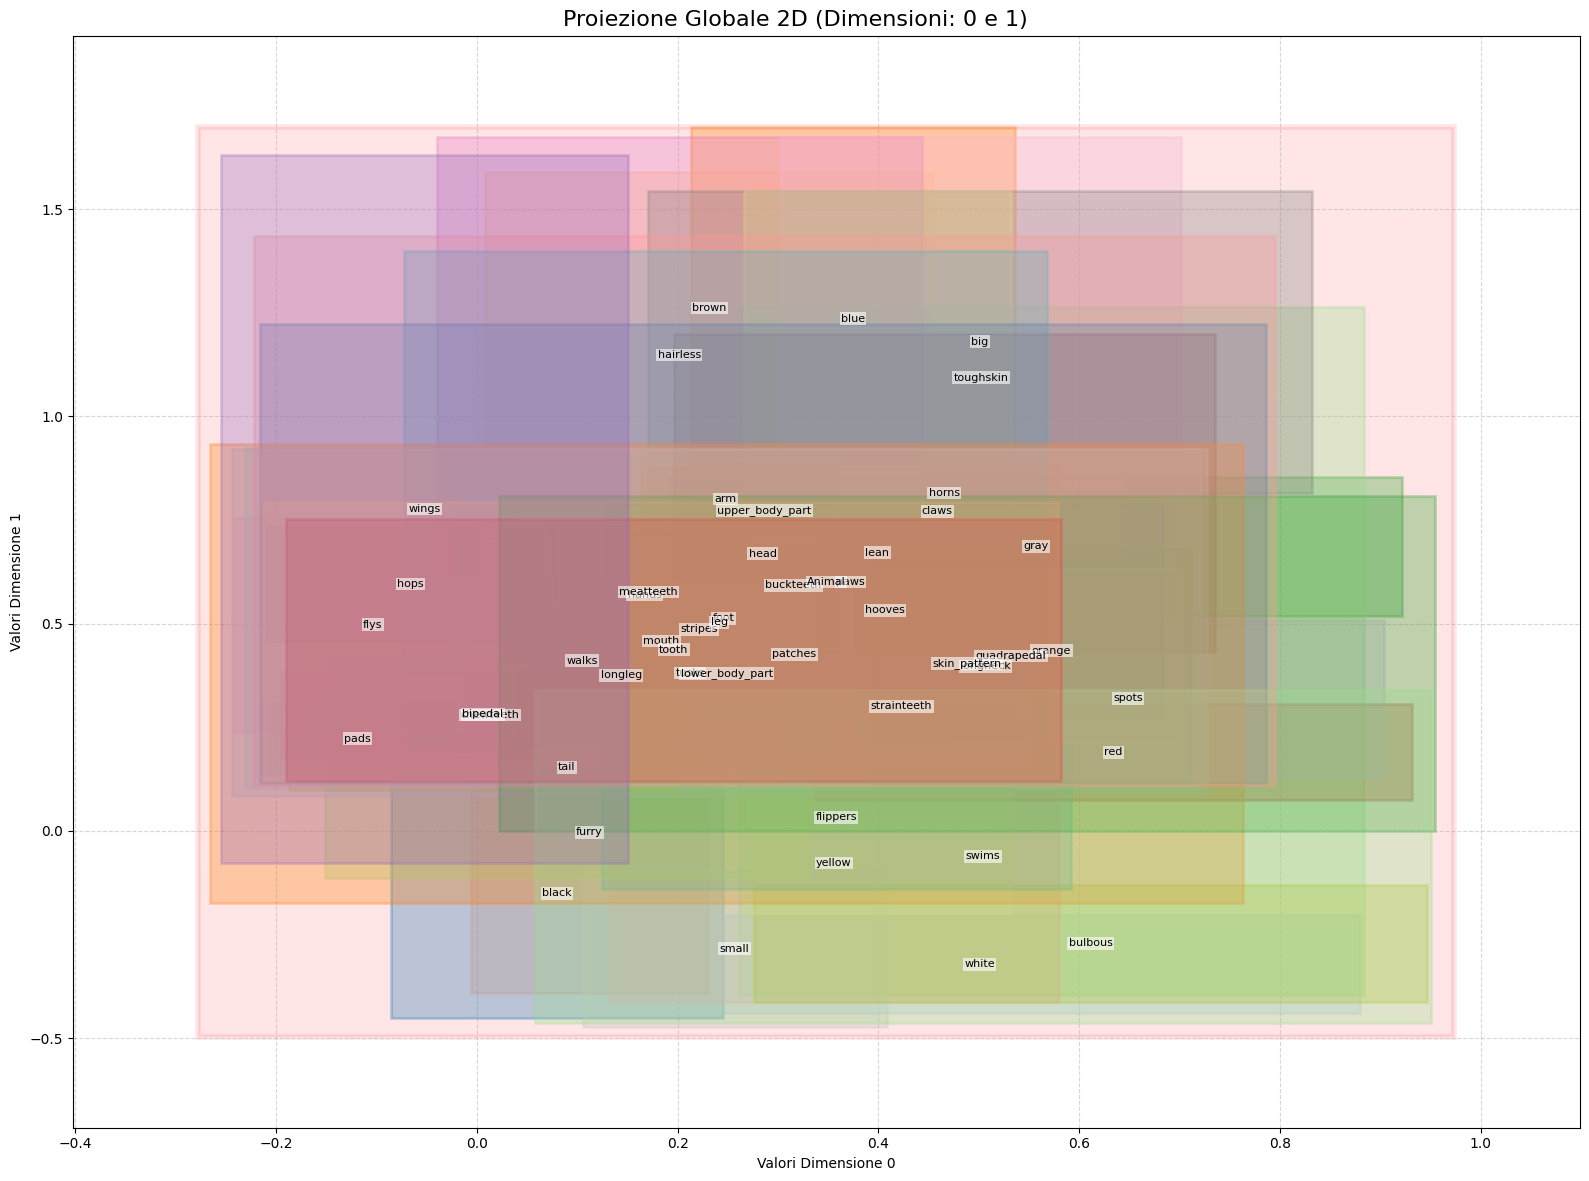

In [11]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(model, id2concept, dim_x=0, dim_y=1)

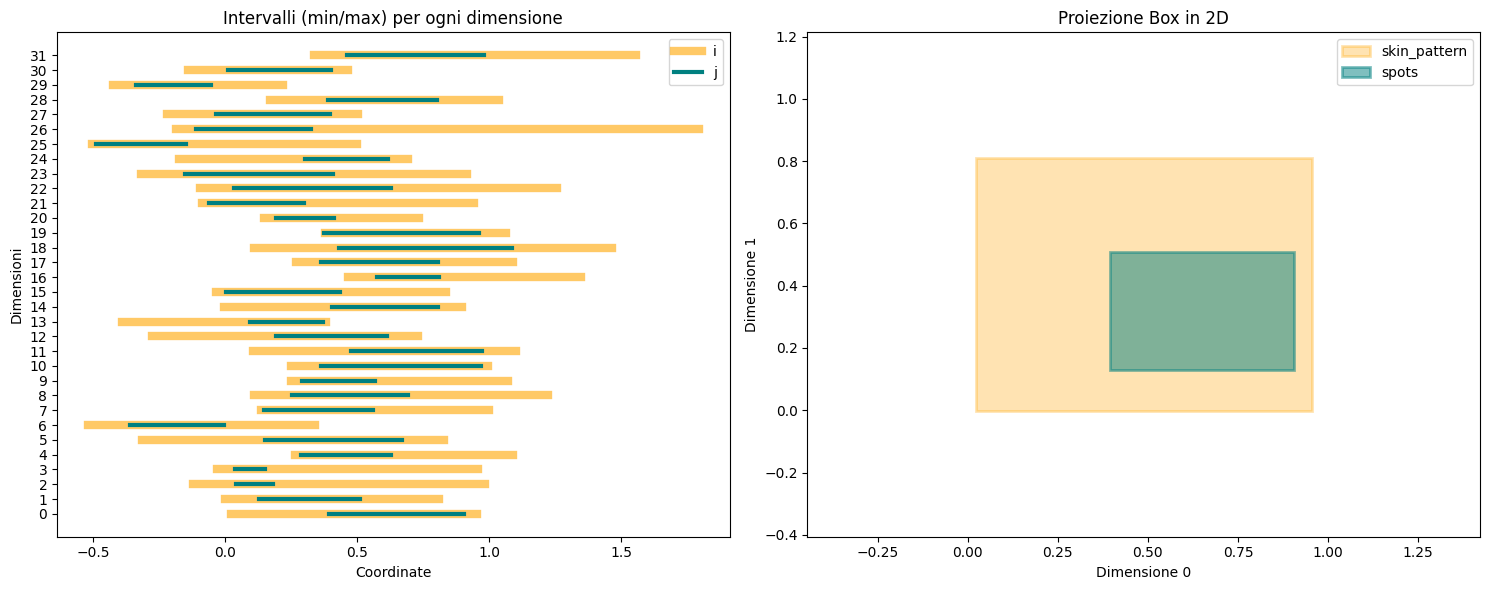

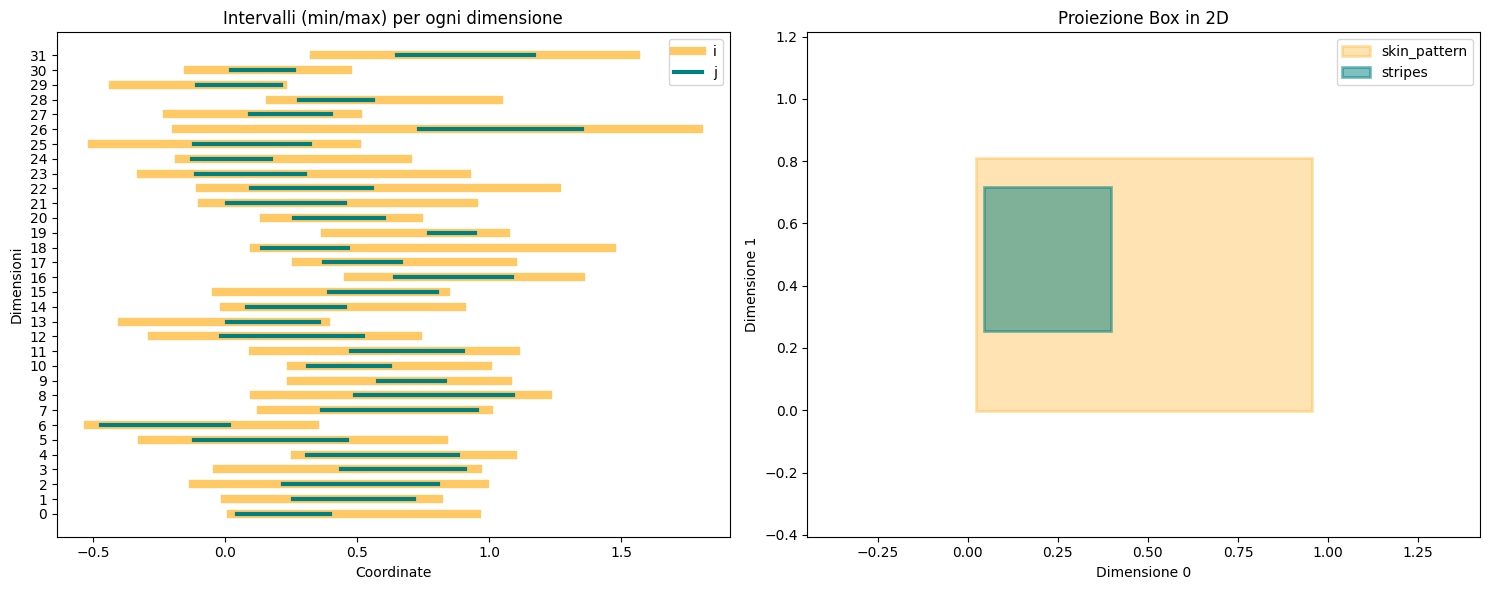

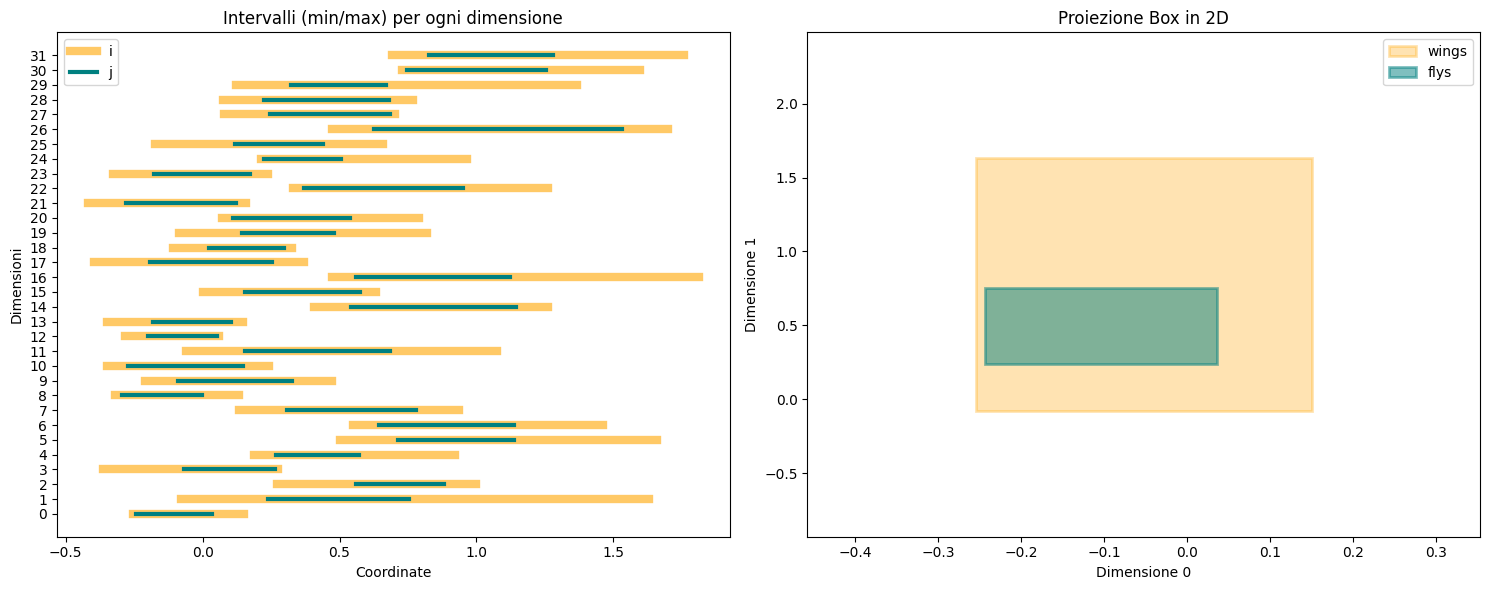

In [12]:
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "spots")
visualize_concept_hierarchy(model, id2concept, concept2id, "skin_pattern", "stripes")
visualize_concept_hierarchy(model, id2concept, concept2id, "wings", "flys")

### Save boxes

In [13]:
from src.CHM.model import get_box_dict

box_dict = get_box_dict(model, id2concept)

In [14]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[0.9739, 1.6974, 1.0626, 1.1479, 1.1175, 1.8058, 1.5476, 1.0141, 1.2298,
         1.0714, 1.0499, 1.1080, 1.0279, 1.4057, 1.3595, 0.8401, 1.8108, 1.1917,
         1.4762, 1.0800, 0.9154, 1.1053, 1.2814, 1.6990, 1.0808, 1.1140, 1.8054,
         1.0401, 1.1260, 1.4801, 1.6574, 1.9309]])
Coordinate z (min) per 'wings': tensor([[-0.2551, -0.0775,  0.2717, -0.3626,  0.1884,  0.5029,  0.5492,  0.1342,
         -0.3216, -0.2093, -0.3511, -0.0603, -0.2828, -0.3505,  0.4062,  0.0012,
          0.4710, -0.3985, -0.1094, -0.0847,  0.0725, -0.4203,  0.3311, -0.3260,
          0.2133, -0.1743,  0.4720,  0.0777,  0.0741,  0.1222,  0.7287,  0.6927]])


## CBM

### Load dataset

In [15]:
import torch
torch.save(model.state_dict(), "modello_gerarchia.pth")

In [16]:
model.load_state_dict(torch.load("modello_gerarchia.pth"))

<All keys matched successfully>

In [17]:
box_dict = get_box_dict(model, id2concept)

In [18]:
box_animale = box_dict["Animal"]
box_ali = box_dict["wings"]

print(f"Coordinate Z (max) per 'Animal': {box_animale.Z}")
print(f"Coordinate z (min) per 'wings': {box_ali.z}")

Coordinate Z (max) per 'Animal': tensor([[0.9739, 1.6974, 1.0626, 1.1479, 1.1175, 1.8058, 1.5476, 1.0141, 1.2298,
         1.0714, 1.0499, 1.1080, 1.0279, 1.4057, 1.3595, 0.8401, 1.8108, 1.1917,
         1.4762, 1.0800, 0.9154, 1.1053, 1.2814, 1.6990, 1.0808, 1.1140, 1.8054,
         1.0401, 1.1260, 1.4801, 1.6574, 1.9309]])
Coordinate z (min) per 'wings': tensor([[-0.2551, -0.0775,  0.2717, -0.3626,  0.1884,  0.5029,  0.5492,  0.1342,
         -0.3216, -0.2093, -0.3511, -0.0603, -0.2828, -0.3505,  0.4062,  0.0012,
          0.4710, -0.3985, -0.1094, -0.0847,  0.0725, -0.4203,  0.3311, -0.3260,
          0.2133, -0.1743,  0.4720,  0.0777,  0.0741,  0.1222,  0.7287,  0.6927]])


In [19]:
from src.utils.dataset import classical_split_awa2_features
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.CHM.model import prepara_tensore_box

features_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-features.txt'
labels_path = '../AwA2_Dataset_Features/Animals_with_Attributes2/Features/ResNet101/AwA2-labels.txt'

(X_train, y_train), (X_val, y_val), (X_test, y_test) = classical_split_awa2_features(
    features_path, labels_path, test_size=0.2, val_size=0.1, random_seed=42
)
class_concept_matrix = torch.from_numpy(np.loadtxt('../Awa2_Dataset_Labels/Animals_with_Attributes2/extended_matrix.txt', dtype=int))

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 20
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)

Caricamento dei dati in corso... (potrebbe richiedere qualche secondo)
Dataset caricato correttamente: 37322 campioni con 2048 feature ciascuno.

--- Risultati dello Split Stratificato (50 Classi) ---
Training set:   26124 campioni
Validation set: 3733 campioni
Test set:       7465 campioni
Using device: cpu


### CBM with boxes

#### Train

In [20]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier


model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

history = train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=0.084, Acc=98.8% | VAL: Loss=0.003, Acc=100.0%
Epoca   3/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.000, Acc=100.0% | VAL: Loss=0.000, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.000, Acc=100.0% | VA

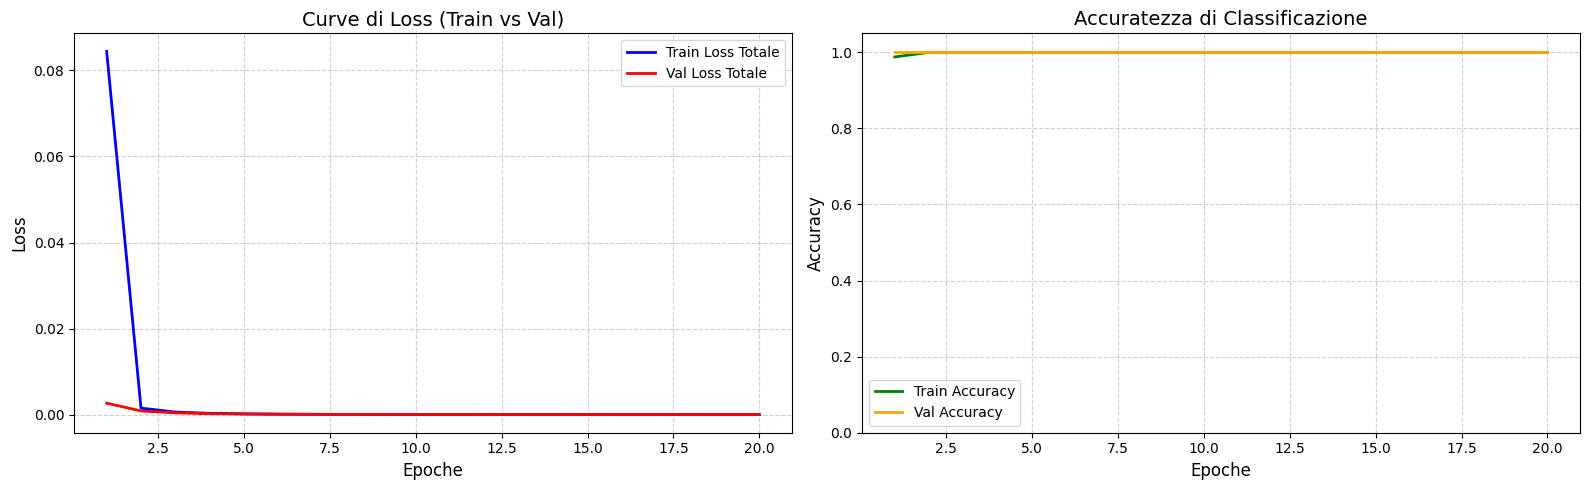

In [21]:
import matplotlib.pyplot as plt

epochs = range(1, len(history['train']['tot_loss']) + 1)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
# --- Grafico 1: Loss di Train vs Validazione ---
ax1.plot(epochs, history['train']['tot_loss'], label='Train Loss Totale', color='blue', linewidth=2)
ax1.plot(epochs, history['val']['tot_loss'], label='Val Loss Totale', color='red', linewidth=2)
    
    
ax1.set_title('Curve di Loss (Train vs Val)', fontsize=14)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
    
# --- Grafico 2: Accuratezza Multi-Classe ---
ax2.plot(epochs, history['train']['acc'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val']['acc'], label='Val Accuracy', color='orange', linewidth=2)
    
ax2.set_title('Accuratezza di Classificazione', fontsize=14)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()

#### Test

In [22]:
from src.CHM.test import test_cbm_classifier, plot_test_results

test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

accuracy, preds, labels = test_cbm_classifier(
     model=model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 100.00% (7465/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       170
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        38
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       149
           6       1.00      1.00      1.00       329
           7       1.00      1.00      1.00       207
           8       1.00      1.00      1.00        35
           9       1.00      1.00      1.00       100

   micro avg       1.00      1.00      1.00      1405
   macro avg       1.00      1.00      1.00      1405
weighted avg       1.00      1.00      1.00      1405



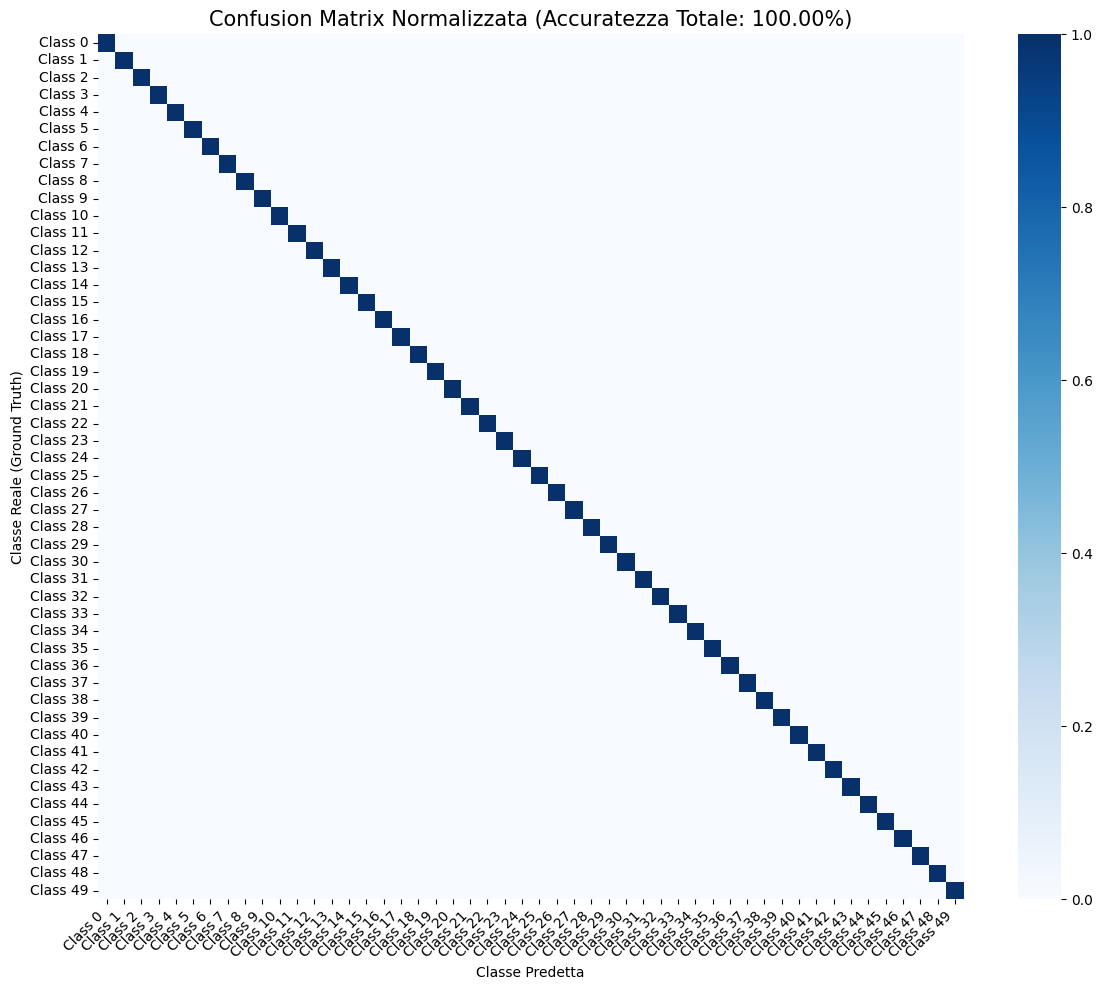


Analisi degli Errori Principali:


In [23]:
plot_test_results(accuracy, preds, labels, class_names=[f"Class {i}" for i in range(NUM_CLASSES)])

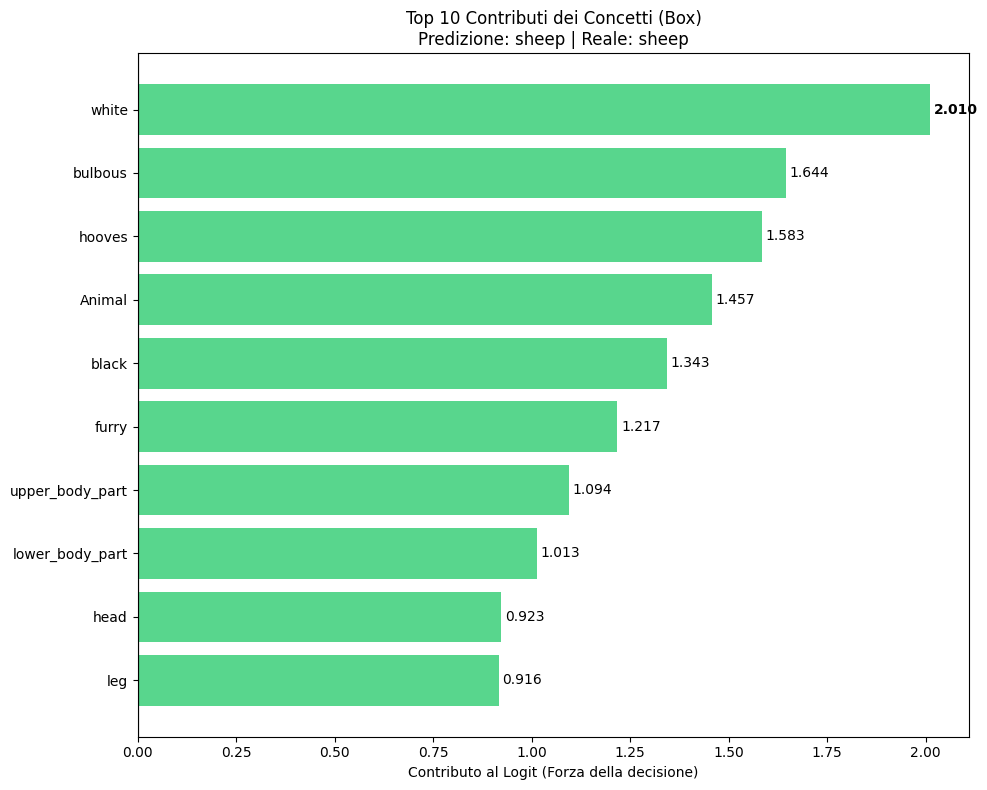

True

In [24]:
from src.CHM.interpretation import explain_prediction

explain_prediction(model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors)

### CBM with cond prob distrib

#### Train

In [25]:
info = "rel_matrix"
model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
history = train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=2.860, Acc=24.9% | VAL: Loss=2.401, Acc=38.1%
Epoca   3/20 | TRAIN: Loss=2.190, Acc=45.4% | VAL: Loss=2.002, Acc=44.0%
Epoca   4/20 | TRAIN: Loss=1.875, Acc=57.9% | VAL: Loss=1.761, Acc=61.7%
Epoca   5/20 | TRAIN: Loss=1.649, Acc=65.6% | VAL: Loss=1.559, Acc=58.9%
Epoca   6/20 | TRAIN: Loss=1.464, Acc=71.5% | VAL: Loss=1.386, Acc=74.4%
Epoca   7/20 | TRAIN: Loss=1.313, Acc=75.1% | VAL: Loss=1.247, Acc=74.6%
Epoca   8/20 | TRAIN: Loss=1.183, Acc=78.8% | VAL: Loss=1.152, Acc=77.7%
Epoca   9/20 | TRAIN: Loss=1.075, Acc=80.6% | VAL: Loss=1.036, Acc=78.2%
Epoca  10/20 | TRAIN: Loss=0.978, Acc=82.9% | VAL: Loss=0.937, Acc=81.8%
Epoca  11/20 | TRAIN: Loss=0.894, Acc=84.4% | VAL: Loss=0.860, Acc=86.7%
Epoca  12/20 | TRAIN: Loss=0.822, Acc=86.0% | VAL: Loss=0.788, Acc=87.0%
Epoca  13/20 | TRAIN: Loss=0.757, Acc=87.4% | VAL: Loss=0.714, Acc=89.6%
Epoca  14/20 | TRAIN: Loss=0.701, Acc=88.1% | VAL: Loss=0.675, Acc=87.1%

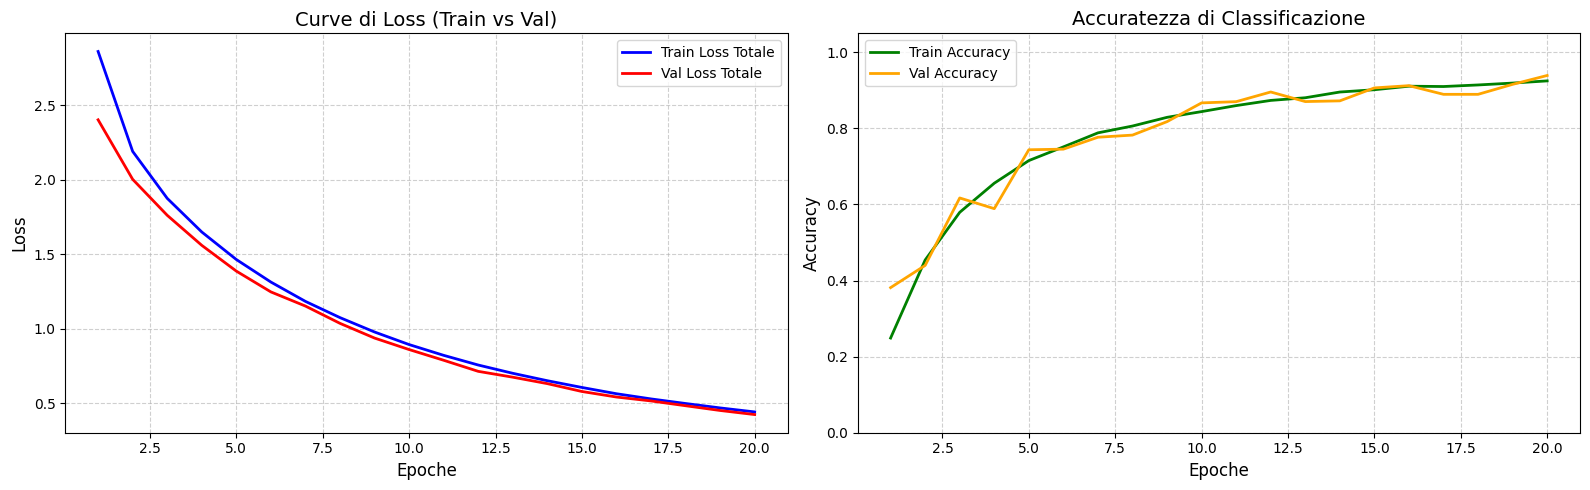

In [26]:
epochs = range(1, len(history['train']['tot_loss']) + 1)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
# --- Grafico 1: Loss di Train vs Validazione ---
ax1.plot(epochs, history['train']['tot_loss'], label='Train Loss Totale', color='blue', linewidth=2)
ax1.plot(epochs, history['val']['tot_loss'], label='Val Loss Totale', color='red', linewidth=2)
    
    
ax1.set_title('Curve di Loss (Train vs Val)', fontsize=14)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
    
# --- Grafico 2: Accuratezza Multi-Classe ---
ax2.plot(epochs, history['train']['acc'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val']['acc'], label='Val Accuracy', color='orange', linewidth=2)
    
ax2.set_title('Accuratezza di Classificazione', fontsize=14)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()

#### Test

In [27]:
accuracy, preds, labels = test_cbm_classifier(
     model=model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 93.93% (7012/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       170
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        38
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       149
           6       1.00      1.00      1.00       329
           7       0.67      1.00      0.81       207
           8       1.00      1.00      1.00        35
           9       0.00      0.00      0.00       100

   micro avg       0.93      0.93      0.93      1405
   macro avg       0.87      0.90      0.88      1405
weighted avg       0.88      0.93      0.90      1405



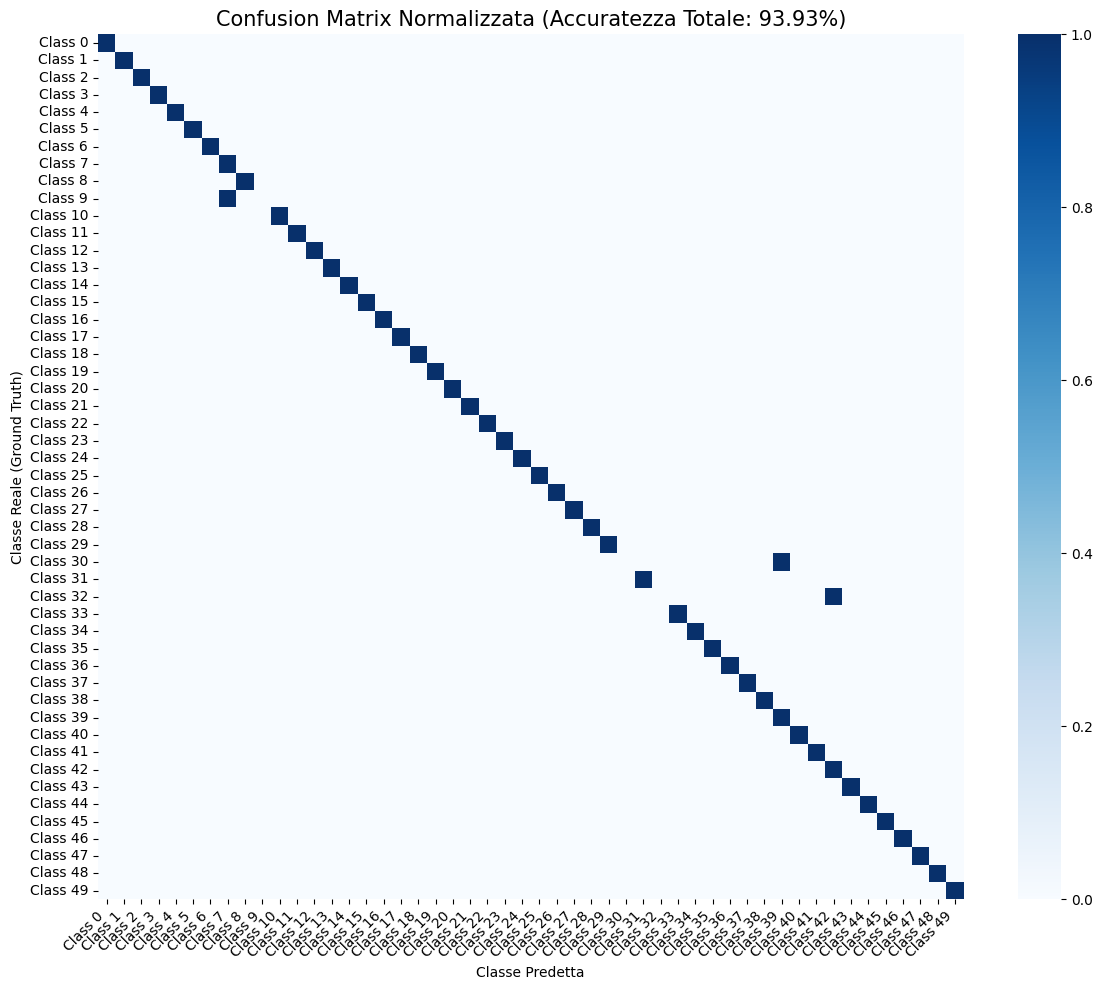


Analisi degli Errori Principali:
 - 240 volte: 'Class 30' è stato scambiato per 'Class 39'
 - 113 volte: 'Class 32' è stato scambiato per 'Class 42'
 - 100 volte: 'Class 9' è stato scambiato per 'Class 7'


In [28]:
plot_test_results(accuracy, preds, labels, class_names=[f"Class {i}" for i in range(NUM_CLASSES)])

1. controllare 100% accuracy sospetto
2. valutare istanza per istanza interpretazione
3. training x -> c_pred

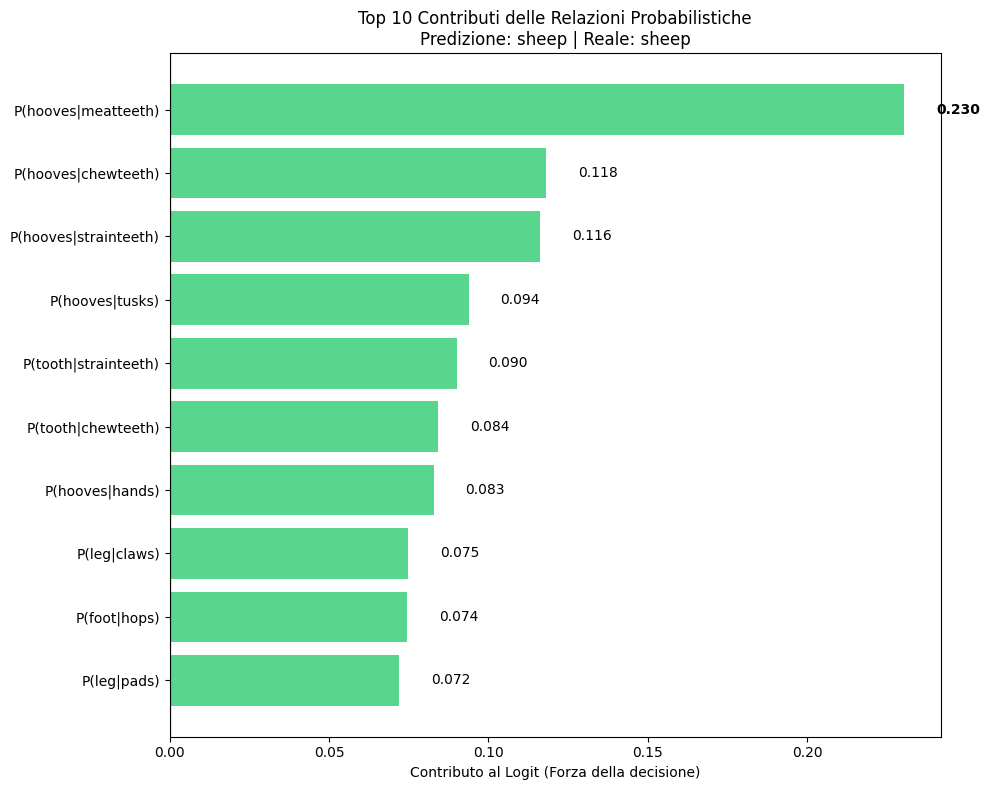

True

In [29]:
from src.CHM.interpretation import explain_prediction

explain_prediction(model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

#### CBM standard

In [30]:
info = "concepts"
model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
history = train_cbm_classifier(
    model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

Inizio addestramento del classificatore (c -> y)...
Epoca   2/20 | TRAIN: Loss=1.582, Acc=82.3% | VAL: Loss=0.508, Acc=98.1%
Epoca   3/20 | TRAIN: Loss=0.287, Acc=99.3% | VAL: Loss=0.159, Acc=100.0%
Epoca   4/20 | TRAIN: Loss=0.109, Acc=100.0% | VAL: Loss=0.074, Acc=100.0%
Epoca   5/20 | TRAIN: Loss=0.055, Acc=100.0% | VAL: Loss=0.041, Acc=100.0%
Epoca   6/20 | TRAIN: Loss=0.032, Acc=100.0% | VAL: Loss=0.025, Acc=100.0%
Epoca   7/20 | TRAIN: Loss=0.020, Acc=100.0% | VAL: Loss=0.016, Acc=100.0%
Epoca   8/20 | TRAIN: Loss=0.013, Acc=100.0% | VAL: Loss=0.010, Acc=100.0%
Epoca   9/20 | TRAIN: Loss=0.008, Acc=100.0% | VAL: Loss=0.007, Acc=100.0%
Epoca  10/20 | TRAIN: Loss=0.005, Acc=100.0% | VAL: Loss=0.004, Acc=100.0%
Epoca  11/20 | TRAIN: Loss=0.004, Acc=100.0% | VAL: Loss=0.003, Acc=100.0%
Epoca  12/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.002, Acc=100.0%
Epoca  13/20 | TRAIN: Loss=0.002, Acc=100.0% | VAL: Loss=0.001, Acc=100.0%
Epoca  14/20 | TRAIN: Loss=0.001, Acc=100.0% | VAL:

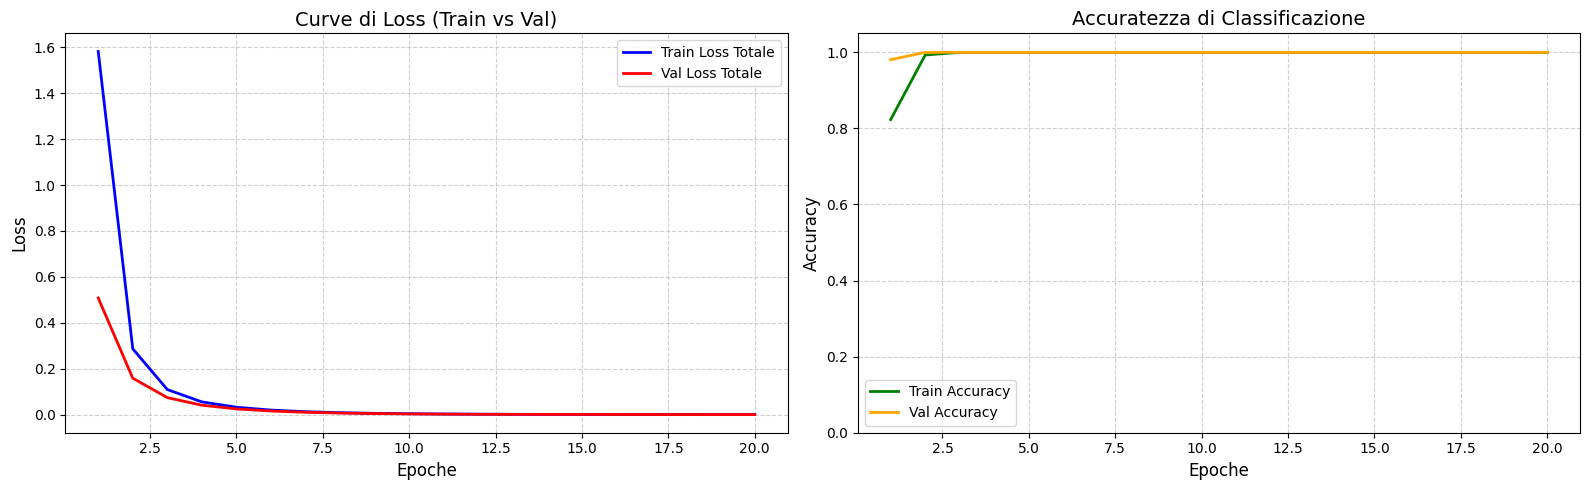

In [31]:
epochs = range(1, len(history['train']['tot_loss']) + 1)
    
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
# --- Grafico 1: Loss di Train vs Validazione ---
ax1.plot(epochs, history['train']['tot_loss'], label='Train Loss Totale', color='blue', linewidth=2)
ax1.plot(epochs, history['val']['tot_loss'], label='Val Loss Totale', color='red', linewidth=2)
    
    
ax1.set_title('Curve di Loss (Train vs Val)', fontsize=14)
ax1.set_xlabel('Epoche', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)
    
# --- Grafico 2: Accuratezza Multi-Classe ---
ax2.plot(epochs, history['train']['acc'], label='Train Accuracy', color='green', linewidth=2)
ax2.plot(epochs, history['val']['acc'], label='Val Accuracy', color='orange', linewidth=2)
    
ax2.set_title('Accuratezza di Classificazione', fontsize=14)
ax2.set_xlabel('Epoche', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_ylim(0, 1.05)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)
    
plt.tight_layout()
plt.show()

In [32]:
accuracy, preds, labels = test_cbm_classifier(
     model=model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info
)

Inizio valutazione sul Test Set...

Risultati Test Set:
Accuratezza Totale: 100.00% (7465/7465)

Classification Report (prime 10 classi):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       209
           1       1.00      1.00      1.00       170
           2       1.00      1.00      1.00        58
           3       1.00      1.00      1.00        38
           4       1.00      1.00      1.00       110
           5       1.00      1.00      1.00       149
           6       1.00      1.00      1.00       329
           7       1.00      1.00      1.00       207
           8       1.00      1.00      1.00        35
           9       1.00      1.00      1.00       100

   micro avg       1.00      1.00      1.00      1405
   macro avg       1.00      1.00      1.00      1405
weighted avg       1.00      1.00      1.00      1405



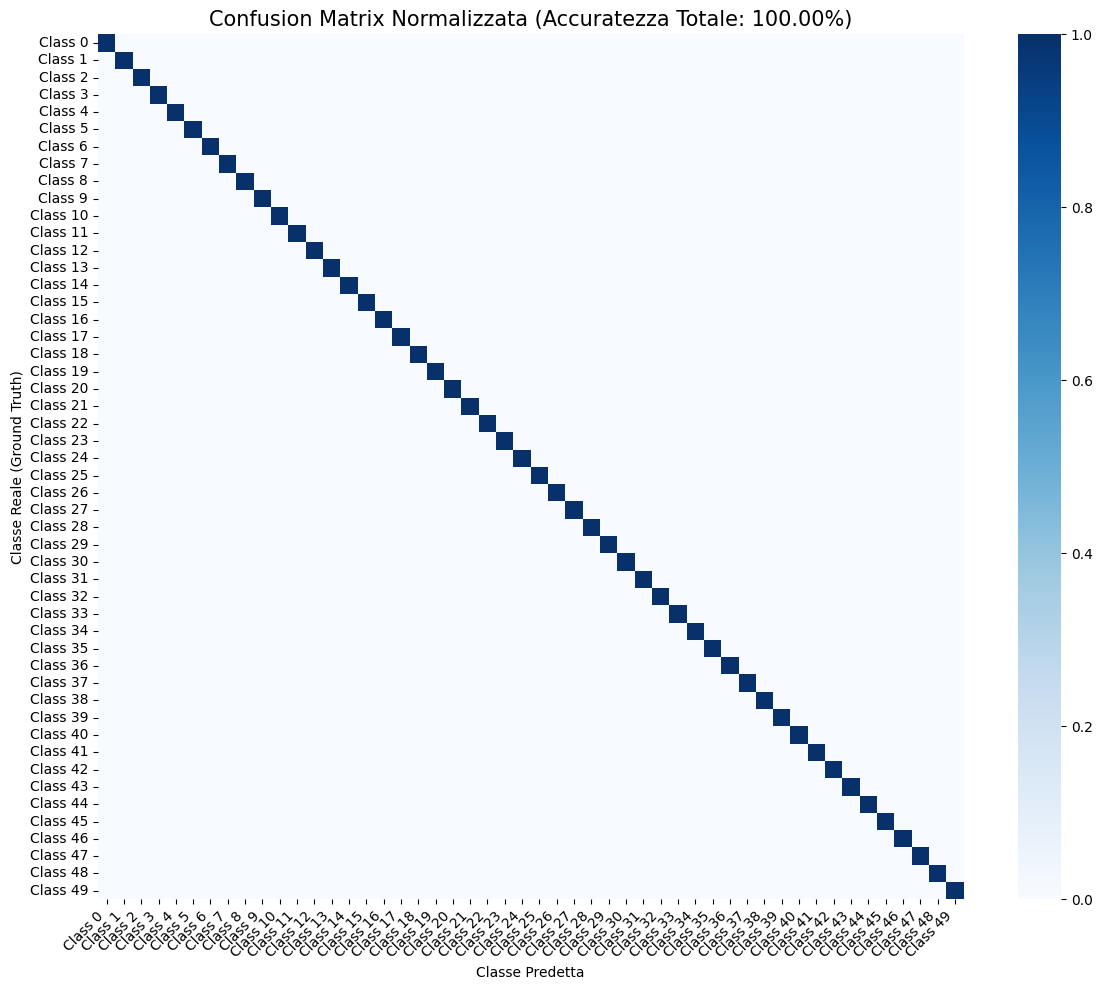


Analisi degli Errori Principali:


In [33]:
plot_test_results(accuracy, preds, labels, class_names=[f"Class {i}" for i in range(NUM_CLASSES)])

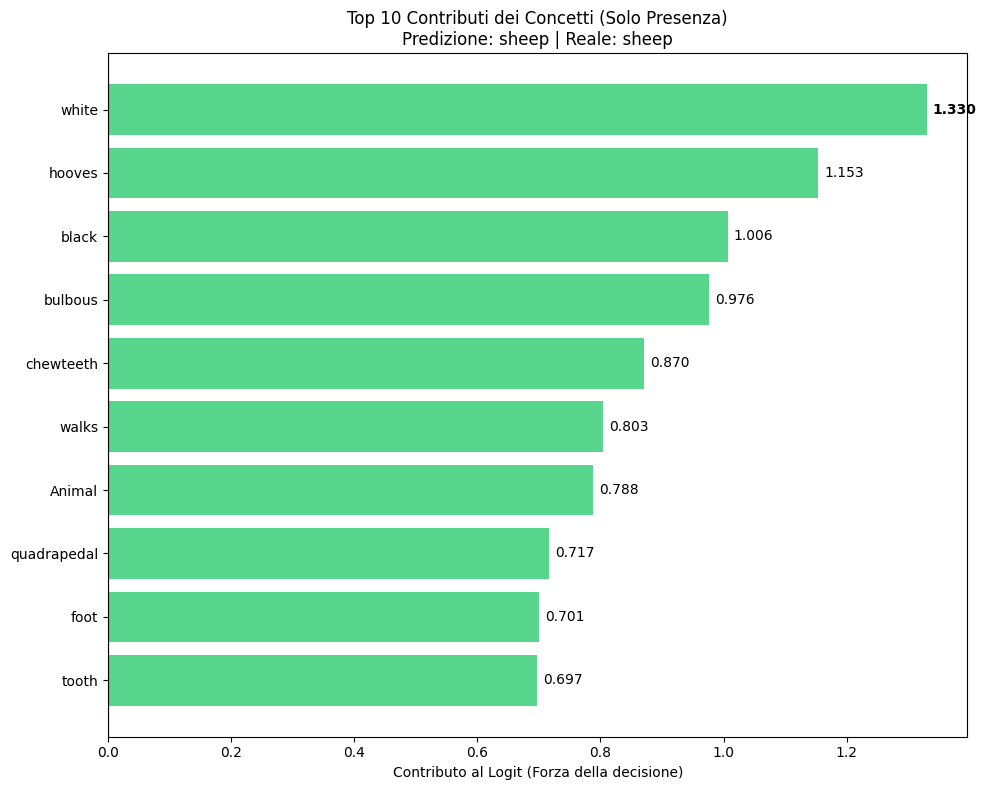

True

In [34]:
from src.CHM.interpretation import explain_prediction

explain_prediction(model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)